# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [130]:
ПІБ = 'Вербицький Юрій Віталійович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 3     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [131]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Вербицький Юрій Віталійович, ШІ-31, варіант 3
ваш потік:                   P>10
ваша пара для графіка 3:     потік E>0.8 та потік P>10
ваш агрегат для етапу 4:     середнє
ваше додаткове питання:      Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [133]:
# ВАШ КОД
df_test = pd.read_excel(ФАЙЛ)

print("Перші 5 рядків")
display(df_test.head())

print("\nТипи стовпців та інформація")
print(df_test.dtypes)

Перші 5 рядків


,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN



Типи стовпців та інформація
Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                         

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*
Тому що заголовок зʼїхав, реальні дані починаються з 25 рядка

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [134]:
# ВАШ КОД
RAW = None
df_test = pd.read_excel(ФАЙЛ, header=None)

print("Перші 30 рядків")
display(df_test.head(30))

Перші 30 рядків


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [135]:
# ВАШ КОД
print(df_test.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*
Три таблиці

1 - 1-14

2 - 16-19

3 - 24-31

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [136]:
# ВАШ КОД
display(df_test.iloc[0:22, [1, 16, 26]])

,1,16,26
0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,http://umtof.umd.edu/pm/crn/
1,NaN,NaN,NaN
2,:Data_list: 20170901_Gs_part_5m.txt,NaN,SOHO CELIAS Proton Monitor
3,:Created: 2017 Sep 02 0011 UTC,NaN,Solar Wind Parameters for Carrington Rotation ...
4,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,Proton speed [km/sec]
5,# Please send comments and suggestions to SWPC...,NaN,Proton density [protons per cubic centimeter]
6,#,NaN,NaN
7,# Label: P > 1 = Particles at >1 Mev,NaN,"Measurement time (Year, Month, Day of Month, D..."
8,# Label: P > 5 = Particles at >5 Mev,NaN,NaN
9,# Label: P >10 = Particles at >10 Mev,NaN,NaN


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | GOES-15  | Protons/cm2-s-sr, Electrons/cm2-s-sr |
| B | NOAA Space Weather Prediction Center | Radio Flux 10.7(з ексель) |
| C | SOHO CELIAS Proton Monitor | km/sec, protons per cubic centimeter |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [137]:
A = df_test.iloc[26:, 1:15].copy()
A.columns = ['year', 'month', 'day', 'time_hhmm', 'julian_day', 'seconds_of_day',
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
A = A.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)

B = df_test.iloc[27:, 16:20].copy()
B.columns = ['year', 'month', 'day', 'radio_flux_F10.7']
B = B.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)

C = df_test.iloc[27:, 26:32].copy()
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']
C = C.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)

print("A:", A.shape)
print("B:", B.shape)
print("C:", C.shape)

A: (7200, 14)
B: (25, 4)
C: (601, 6)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [138]:
A['hour'] = A['time_hhmm'].astype(int) // 100
A['minute'] = A['time_hhmm'].astype(int) % 100

A['ts'] = pd.to_datetime({
    'year': 2017,
    'month': A['month'].astype(int),
    'day': A['day'].astype(int),
    'hour': A['hour'],
    'minute': A['minute']
})

B['ts'] = pd.to_datetime({
    'year': 2017,
    'month': B['month'].astype(int),
    'day': B['day'].astype(int)
})

C['ts'] = pd.to_datetime({
    'year': 2017,
    'month': C['month'].astype(int),
    'day': C['day'].astype(int),
    'hour': C['hour'].astype(int)
})

print("Таблиця A:", A['ts'].min(), "—", A['ts'].max())
print("Таблиця B:", B['ts'].min(), "—", B['ts'].max())
print("Таблиця C:", C['ts'].min(), "—", C['ts'].max())

Таблиця A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
Таблиця B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
Таблиця C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [139]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [140]:
# ВАШ КОД
for name, df in [('A', A), ('B', B), ('C', C)]:
    print(f"ТАБЛИЦЯ {name}")

    print("\nРозмір:")
    print(df.shape)

    print("\nТипи стовпців:")
    print(df.dtypes)

    print("\nКількість пропусків у кожному стовпці:")
    print(df.isna().sum())

    print("\nКількість повних дублікатів рядків:")
    print(df.duplicated().sum())

    print("\nОписова статистика:")
    print(df.describe())

ТАБЛИЦЯ A

Розмір:
(7200, 17)

Типи стовпців:
year                       int64
month                      int64
day                        int64
time_hhmm                  int64
julian_day                 int64
seconds_of_day             int64
P>1                      float64
P>5                      float64
P>10                     float64
P>30                     float64
P>50                     float64
P>100                    float64
E>0.8                    float64
E>2.0                    float64
hour                       int64
minute                     int64
ts                datetime64[ns]
dtype: object

Кількість пропусків у кожному стовпці:
year              0
month             0
day               0
time_hhmm         0
julian_day        0
seconds_of_day    0
P>1               3
P>5               3
P>10              3
P>30              3
P>50              3
P>100             3
E>0.8             3
E>2.0             3
hour              0
minute            0
ts                0

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [141]:
# ВАШ КОД
import numpy as np

print("Від'ємних speed:", (C['speed'] < 0).sum())
print("Від'ємних density:", (C['density'] < 0).sum())

print("\nДо очищення:")
print(C[['speed', 'density']].describe().loc[['mean', 'min']])

C.loc[C['speed'] < 0, 'speed'] = np.nan
C.loc[C['density'] < 0, 'density'] = np.nan

print("\nПісля очищення:")
print(C[['speed', 'density']].describe().loc[['mean', 'min']])

Від'ємних speed: 8
Від'ємних density: 8

До очищення:
           speed   density
mean  506.547421  2.907654
min    -1.000000 -1.000000

Після очищення:
           speed   density
mean  513.394604  2.960371
min   277.000000  0.100000


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*
Це службові значення, коли дані не змогли бути визначеними
їх по 8 штук

506.547421 - 513.394604

2.907654 - 2.960371

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [142]:
# ВАШ КОД
print(A.describe())

         year        month          day    time_hhmm    julian_day  seconds_of_day           P>1          P>5         P>10         P>30         P>50       P>100          E>0.8          E>2.0  \
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000     7200.000000   7197.000000  7197.000000  7197.000000  7197.000000  7197.000000  7197.00000    7197.000000    7197.000000   
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000    43050.000000    689.325064   156.626057    76.474020    18.838604     7.446840     1.65929   81862.741801   11401.502123   
min    2017.0     8.000000     1.000000     0.000000  57993.000000        0.000000      0.429000     0.151000     0.117000     0.057600     0.045500     0.02240       4.300000       0.133000   
25%    2017.0     9.000000     7.000000   588.750000  57999.000000    21525.000000     11.700000     0.279000     0.186000     0.098400     0.059700     0.02630   22200.000000     552.000000   
50%    2017.0     9.000000    

**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*
У таблиці A є стовпці year, month, day і time_hhmm, julian_day і seconds_of_day які описують дату та час, а не результати вимірювань. Тому їхнє середнє значення не має фізичного змісту. Наприклад, середнє time_hhmm = 1177.5 не означає реальний середній час, оскільки час записаний у форматі HHMM.


---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [143]:
# ВАШ КОД
flows = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_hourly = A.set_index('ts')[flows].resample('1h').agg(['mean', 'max']).reset_index()

A_hourly.head()

ts       P>1              P>5             P>10             P>30              P>50             P>100                 E>0.8                 E>2.0        
                           mean    max      mean    max      mean    max      mean     max      mean     max      mean     max          mean      max         mean     max
0 2017-08-28 00:00:00  9.778333  19.40  0.324917  0.690  0.192917  0.314  0.098850  0.2240  0.077583  0.1780  0.040692  0.0793  20941.666667  23600.0  1011.583333  1180.0
1 2017-08-28 01:00:00  7.994167  13.60  0.291667  0.512  0.156583  0.259  0.072583  0.0919  0.058700  0.0798  0.029950  0.0471  18091.666667  20600.0   713.000000   907.0
2 2017-08-28 02:00:00  6.099167  10.80  0.283000  0.479  0.177667  0.321  0.084450  0.1210  0.069642  0.1110  0.035025  0.0595  14108.333333  15000.0   380.833333   475.0
3 2017-08-28 03:00:00  4.752500   7.76  0.236833  0.329  0.166333  0.244  0.087658  0.1800  0.068092  0.1390  0.035517  0.0818  12766.666667  13100.0   267.916667   284.0
4 2017-08-28 04:00:00  4.158333   6.62  0.334917  0.539  0.208333  0.309  0.084800  0.1530  0.072850  0.1420  0.039708  0.0694  11333.333333  12300.0   203.000000   234.0

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

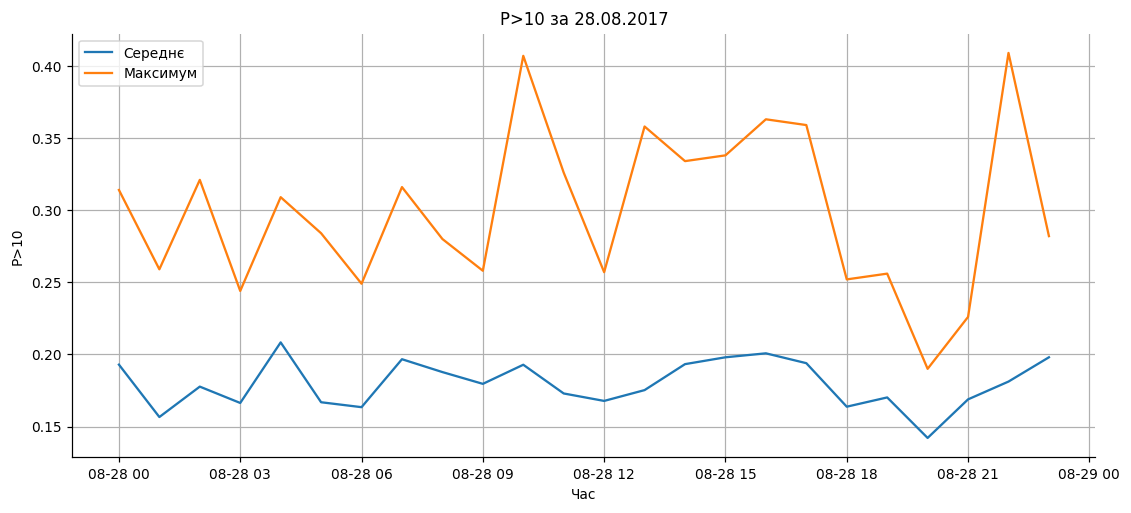

In [144]:
# ВАШ КОД
import matplotlib.pyplot as plt

day = A_hourly[A_hourly['ts'].dt.date == pd.Timestamp('2017-08-28').date()]

plt.figure(figsize=(12, 5))
plt.plot(day['ts'], day[('P>10', 'mean')], label='Середнє')
plt.plot(day['ts'], day[('P>10', 'max')], label='Максимум')

plt.xlabel('Час')
plt.ylabel('P>10')
plt.title('P>10 за 28.08.2017')
plt.legend()
plt.grid()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*
Крива mean логічно розташована нижче кривої max, думаю, що особливо критичними є випадки коли наш max стрибає різко. Mean повністю згладжує це, але саме такі спалахи можуть бути критичними для виявлення загрози(для супутників чи ще щось)

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [145]:
A_hourly.columns = [
    'ts',
    'P>1_mean', 'P>1_max',
    'P>5_mean', 'P>5_max',
    'P>10_mean', 'P>10_max',
    'P>30_mean', 'P>30_max',
    'P>50_mean', 'P>50_max',
    'P>100_mean', 'P>100_max',
    'E>0.8_mean', 'E>0.8_max',
    'E>2.0_mean', 'E>2.0_max'
]

In [146]:
B_hourly = B.loc[B.index.repeat(24)].copy()

B_hourly['ts'] = B_hourly['ts'] + pd.to_timedelta(
    B_hourly.groupby(level=0).cumcount(), unit='h'
)

B_hourly = B_hourly.reset_index(drop=True)

print(B_hourly[['ts']].head(25))

                    ts
0  2017-08-28 00:00:00
1  2017-08-28 01:00:00
2  2017-08-28 02:00:00
3  2017-08-28 03:00:00
4  2017-08-28 04:00:00
5  2017-08-28 05:00:00
6  2017-08-28 06:00:00
7  2017-08-28 07:00:00
8  2017-08-28 08:00:00
9  2017-08-28 09:00:00
10 2017-08-28 10:00:00
11 2017-08-28 11:00:00
12 2017-08-28 12:00:00
13 2017-08-28 13:00:00
14 2017-08-28 14:00:00
15 2017-08-28 15:00:00
16 2017-08-28 16:00:00
17 2017-08-28 17:00:00
18 2017-08-28 18:00:00
19 2017-08-28 19:00:00
20 2017-08-28 20:00:00
21 2017-08-28 21:00:00
22 2017-08-28 22:00:00
23 2017-08-28 23:00:00
24 2017-08-29 00:00:00


In [147]:
M_inner = A_hourly.merge(B_hourly, on='ts', how='inner')
M_inner = M_inner.merge(C, on='ts', how='inner')

In [148]:
M_outer = A_hourly.merge(B_hourly, on='ts', how='outer')
M_outer = M_outer.merge(C, on='ts', how='outer')

In [149]:
print("INNER:", M_inner.shape)
print("OUTER:", M_outer.shape)

INNER: (600, 27)
OUTER: (601, 27)


In [150]:
extra = M_outer[~M_outer['ts'].isin(M_inner['ts'])]

print(extra)

            ts  P>1_mean  P>1_max  P>5_mean  P>5_max  P>10_mean  P>10_max  P>30_mean  P>30_max  P>50_mean  P>50_max  P>100_mean  P>100_max  E>0.8_mean  E>0.8_max  E>2.0_mean  E>2.0_max  year_x  \
600 2017-09-22       NaN      NaN       NaN      NaN        NaN       NaN        NaN       NaN        NaN       NaN         NaN        NaN         NaN        NaN         NaN        NaN     NaN   

     month_x  day_x  radio_flux_F10.7  year_y  month_y  day_y  hour  speed  density  
600      NaN    NaN               NaN    17.0      9.0   22.0   0.0  381.0      1.0  


In [151]:
# ВАШ КОД
M = A_hourly.merge(B_hourly, on='ts', how='outer')
M = M_outer.merge(C, on='ts', how='outer')


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*
Обрано outer, так як він зберіг на один запис з таблиці C більше. Задля збереження всіх даних обрано його

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [152]:
# ВАШ КОД
M['група'] = pd.cut(
    M['P>10_max'],
    bins=[-float('inf'), 10, 1000, float('inf')],
    labels=['тиха', 'активна', 'дуже активна'],
    right=False
)

print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [153]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 76.45421796717173
Медіана: 0.34329166666666666


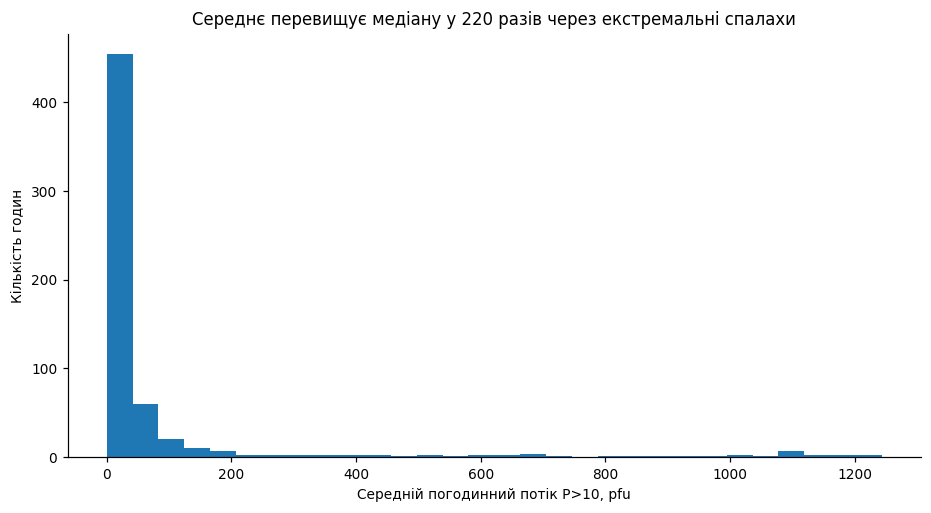

In [154]:
# ВАШ КОД

import matplotlib.pyplot as plt

print("Середнє:", M['P>10_mean'].mean())
print("Медіана:", M['P>10_mean'].median())

plt.figure(figsize=(10, 5))
plt.hist(M['P>10_mean'].dropna(), bins=30)

plt.xlabel('Середній погодинний потік P>10, pfu')
plt.ylabel('Кількість годин')
plt.title('Середнє перевищує медіану у 220 разів через екстремальні спалахи')

plt.show()

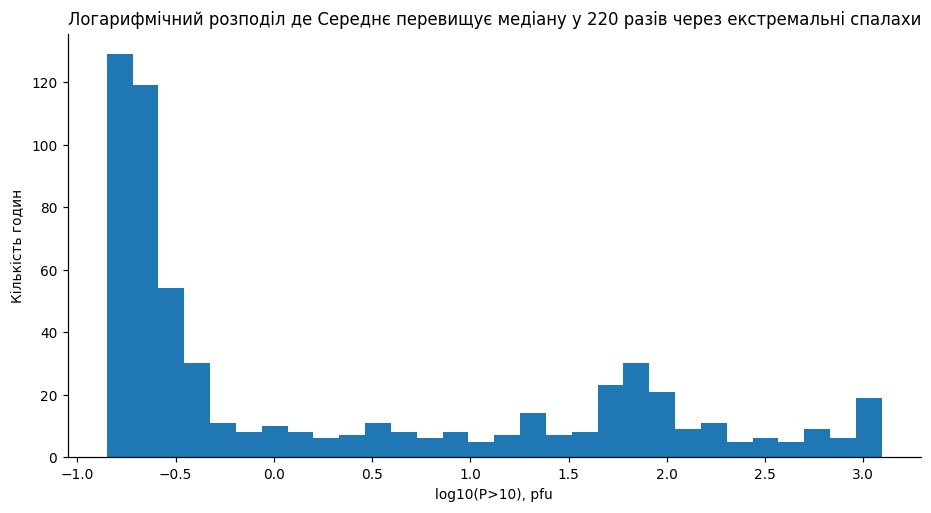

In [155]:
import numpy as np

p10 = M['P>10_mean'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(p10), bins=30)

plt.xlabel('log10(P>10), pfu')
plt.ylabel('Кількість годин')
plt.title('Логарифмічний розподіл де Середнє перевищує медіану у 220 разів через екстремальні спалахи')

plt.show()

**Висновок:**

Значення розподілені дуже нерівномірно, майже весь час рівень викидів дуже низький (близько 0.3 pfu), і лише бувають поодинокі, але дуже сильні сплески. ' Також видно ще один пік в районі 1.6 - 2.0 pfu. Через які наше середнє настільки вище від медіани(медіана ж показує рівно значення, яке знаходиться посередині)

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

<Figure size 1100x550 with 0 Axes>

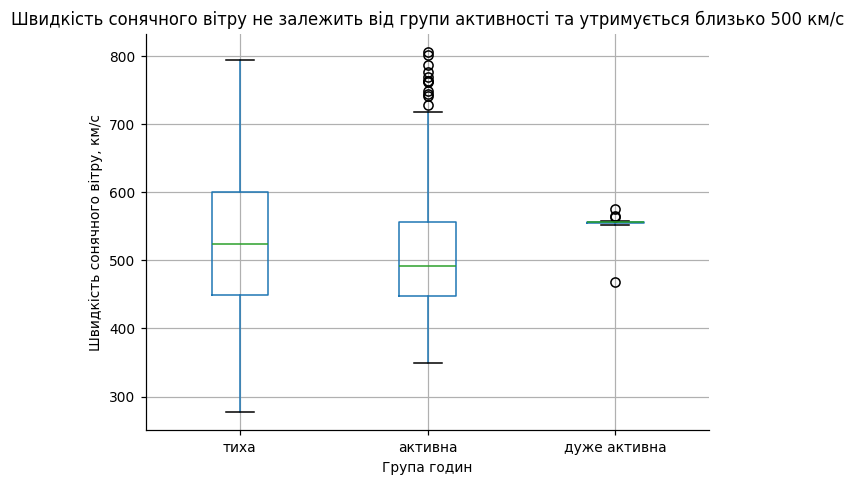

In [156]:
plt.figure(figsize=(10, 5))

M.boxplot(column='speed_x', by='група')

plt.xlabel('Група годин')
plt.ylabel('Швидкість сонячного вітру, км/с')
plt.title('Швидкість сонячного вітру не залежить від групи активності та утримується близько 500 км/с')
plt.suptitle('')

plt.show()

**Висновок:**

Швидкість сонячного вітру практично не залежить від групи активності: для «тихих» і «активних» годин вона майже однакова (прблизно 500 км/с), а для «дуже активних» даних недостатньо чи вони викривлені.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

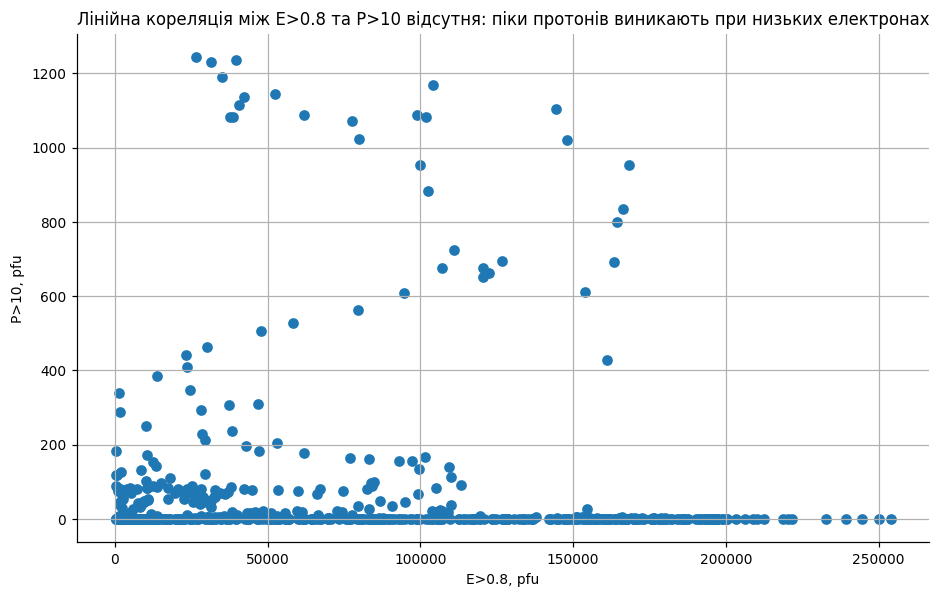

In [157]:
# ВАШ КОД
plt.figure(figsize=(10, 6))

plt.scatter(M['E>0.8_mean'], M['P>10_mean'])
plt.xlabel('E>0.8, pfu')
plt.ylabel('P>10, pfu')
plt.title('Лінійна кореляція між E>0.8 та P>10 відсутня: піки протонів виникають при низьких електронах')
plt.grid()
plt.show()

**Висновок:**
Між E>0.8 та P>10 немає лінійного зв'язку, найвищі піки протонів (понад 1000 pfu) бувають при малих значеннях електронів (до 50000 pfu), а при максимальних електронах (понад 150000) протонів майже немає.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

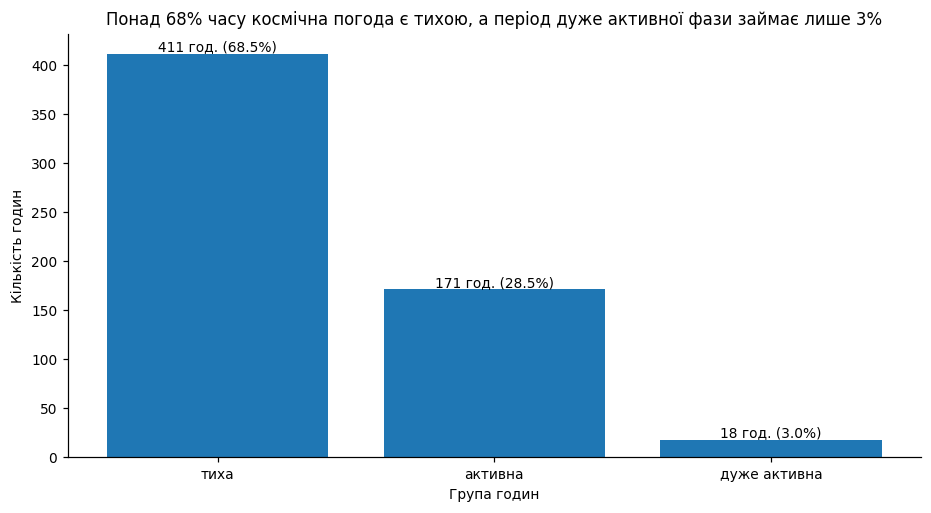

In [158]:
# ВАШ КОД
counts = M['група'].value_counts().sort_index()
total = counts.sum()

plt.figure(figsize=(10, 5))

bars = plt.bar(counts.index, counts.values)

plt.xlabel('Група годин')
plt.ylabel('Кількість годин')
plt.title('Понад 68% часу космічна погода є тихою, а період дуже активної фази займає лише 3%')

for bar, count in zip(bars, counts.values):
    percent = count / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} год. ({percent:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.show()

**Висновок:**
Більшість часу сонячна обстановка залишається тихою - 411 годин, на активний стан припадає 171 година, а період дуже активної фази займає лише 18 годин.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

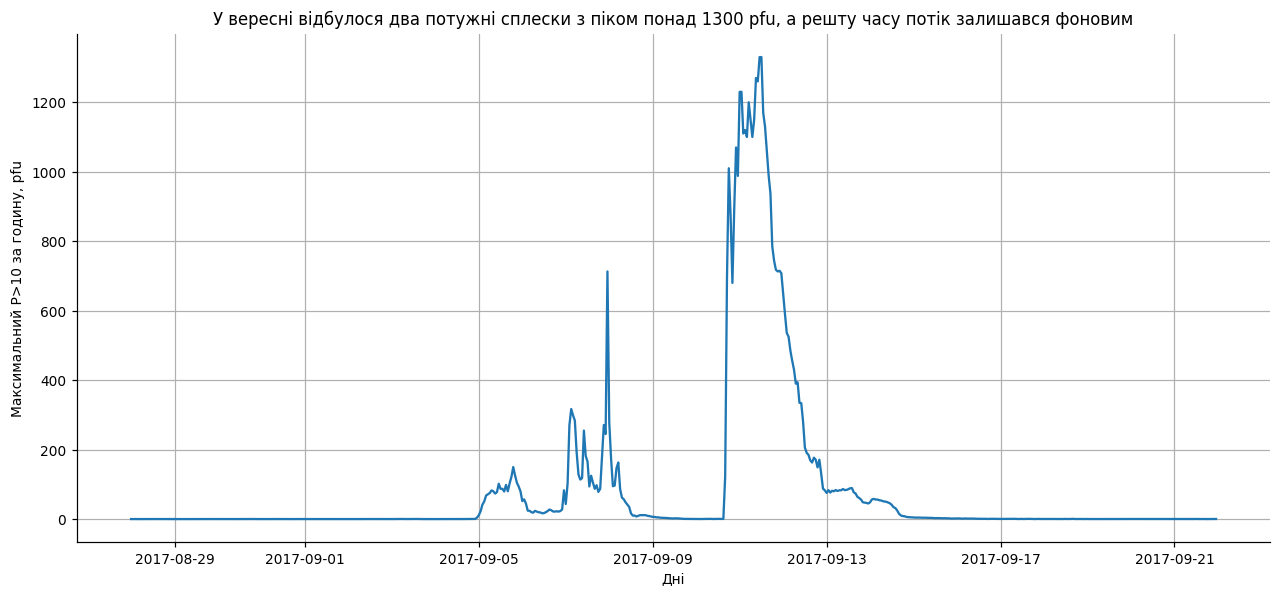

In [159]:
# ВАШ КОД
plt.figure(figsize=(14, 6))

plt.plot(M['ts'], M['P>10_max'])

plt.xlabel('Дні')
plt.ylabel('Максимальний P>10 за годину, pfu')
plt.title('У вересні відбулося два потужні сплески з піком понад 1300 pfu, а решту часу потік залишався фоновим')

plt.grid()
plt.show()

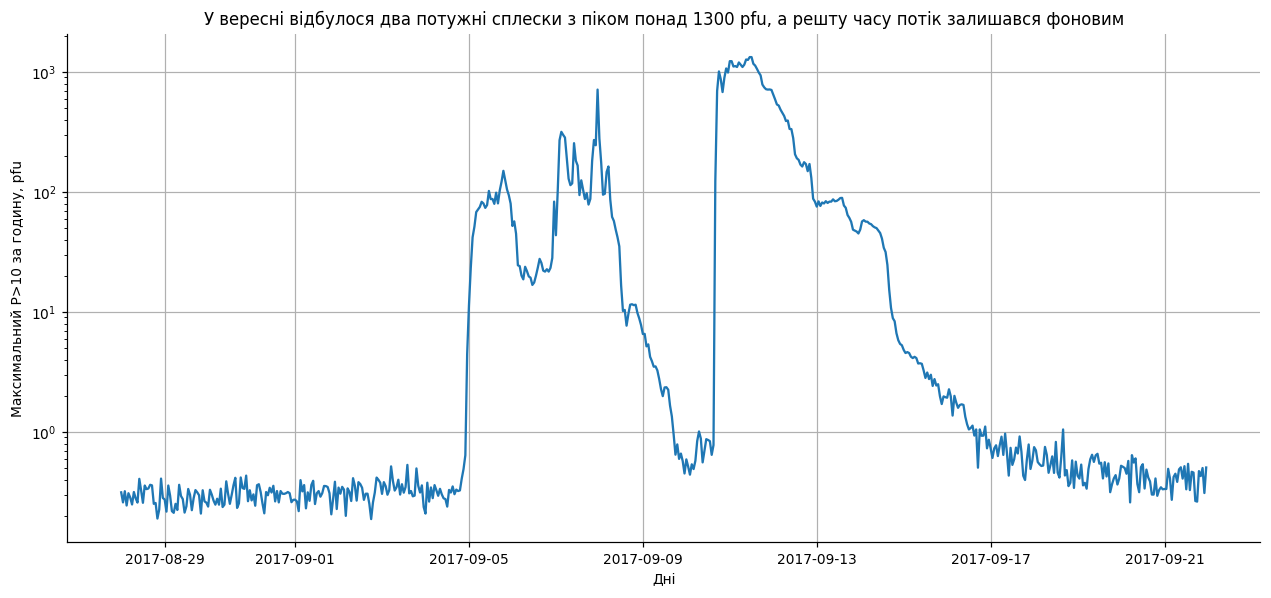

In [160]:
plt.figure(figsize=(14, 6))

plt.plot(M['ts'], M['P>10_max'])

plt.xlabel('Дні')
plt.ylabel('Максимальний P>10 за годину, pfu')
plt.title('У вересні відбулося два потужні сплески з піком понад 1300 pfu, а решту часу потік залишався фоновим')

plt.yscale('log')
plt.grid()
plt.show()

**Висновок:**

На графіку чітко видно два окремі спалахи: перший був 5-9 вересня (з піком до 800 pfu), а другий, ще потужніший - 10-16 вересня, де потік перевищив 1000 pfu, тоді як решту часу потік був менше 1pfu.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

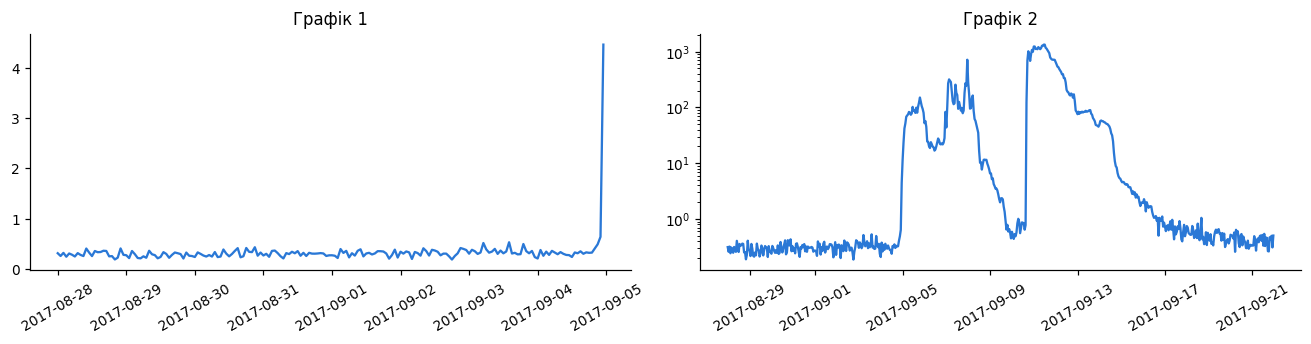

In [161]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка:

У період з 28 серпня по 4 вересня космічна погода була повністю спокійною (потік був низьким і стабільним), і лише наприкінці дня 4 вересня / 5 вересня стався один незначний і короткий сплеск активності.

2. Висновок з другого графіка:

У вересні 2017 року відбулися два потужні сонячні спалахи (перший — 5–9 вересня, другий — 10–16 вересня), під час яких потік протонів зростав до 1000 pfu і вище, а між ними та після них спостерігалися тривалі фази затишшя.

3. Дві відмінності між ними:

  Різний часовий прміжок(1 графік 28.08-05.09, 2 графік 29.08-21.09)
  Різна розмірність осі Y(1 графік звичайна лінійна шкала, 2 графік логарифмічна шкала

### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

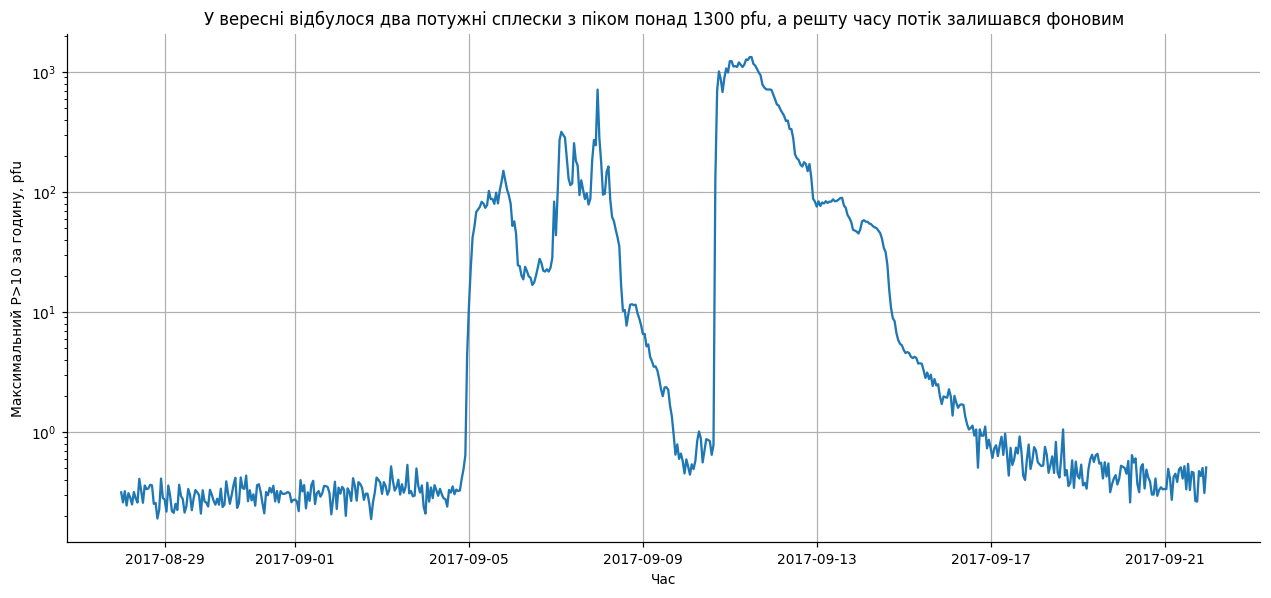

In [162]:
# ВАШ КОД
plt.figure(figsize=(14, 6))

plt.plot(M['ts'], M['P>10_max'])

plt.xlabel('Час')
plt.ylabel('Максимальний P>10 за годину, pfu')
plt.title('У вересні відбулося два потужні сплески з піком понад 1300 pfu, а решту часу потік залишався фоновим')

plt.yscale('log')
plt.grid()

plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Для остаточного графіка було вибрано максимальний погодинний потік P>10 за весь період спостережень(вересень в основному). Для осі Y використано логарифмічну шкалу, оскільки значення потоку мають великий діапазон і містять значні піки, а на логарифмічній шкалі це набагато краще видно.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**

Більшість спостережуваного часу - 411 годин - це «тихий» стан, тоді як на «дуже активний» стан припадає лише 18 годин.

**Спостереження 2:**

Швидкість сонячного вітру не зростає з активністю: у «тихі» години медіана швидкості вища (525 км/с), ніж в «активні» (490 км/с), а в «дуже активні» всі значення взагалі однакові (близько 555 км/с)

**Спостереження 3:**

Спалах сонячної активності відбувається миттєво (потік P>10 зростає з 1 до 1000 pfu менш ніж за добу 10 вересня), проте повернення до фонового рівня є тривалим і займає майже 7 діб (з 11 по 17 вересня).


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?

In [163]:

total_sum = M['P>10_mean'].sum()

peak_idx = M['P>10_mean'].idxmax()

window_24h = M.loc[peak_idx - 12 : peak_idx + 11, 'P>10_mean']
sum_24h = window_24h.sum()

share_percent = (sum_24h / total_sum) * 100

print(f"Сума за 24 години біля піку: {sum_24h:.2f}")
print(f"Загальна сума за весь період: {total_sum:.2f}")
print(f"Частка: {share_percent:.1f}%")

Сума за 24 години біля піку: 24275.42
Загальна сума за весь період: 45872.53
Частка: 52.9%


**Відповідь 7.2:**

за 24 години навколо піку сонячного спалаху сумарний потік склав 24275.42 pfu, що становить 52.9% від загального потоку за увесь розгляданий період.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [164]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'синтаксис',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Знайшов помилку в merge таблиць, (з самого початку вибрав не ті колонки). Також інколи просив пояснити результати згідно предметної області(pfu, сплески)'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [165]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Вербицький Юрій Віталійович
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Знайшов помилку в merge таблиць, (з самого початку вибрав не ті колонки). Також інколи просив пояснити результати згідно предметної області(pfu, сплески)
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [166]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 34)


In [167]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
